In [44]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Model
from keras.losses import MeanSquaredError, CategoricalCrossentropy, Huber
from keras.optimizers import AdamW

In [2]:
DATASET_DIR = "/mnt/e/Deep Learning/data/object-detection-akhavan/object-detection-notebooks/dataset2"
IMAGES_PATH = "/mnt/e/Deep Learning/data/object-detection-akhavan/object-detection-notebooks/dataset2/images"
ANNOTATIONS_PATH = "/mnt/e/Deep Learning/data/object-detection-akhavan/object-detection-notebooks/dataset2/annotations"

print(f"Number of classe is: {len(os.listdir(IMAGES_PATH))}")
print(f"Classes are: {[ name.split('.')[0] for name in os.listdir(ANNOTATIONS_PATH)]}")

Number of classe is: 3
Classes are: ['airplane', 'face', 'motorcycle']


In [18]:
class_names = [name.split('.')[0] for name in os.listdir(ANNOTATIONS_PATH)]
class_names

['airplane', 'face', 'motorcycle']

In [3]:
list_csv_path = glob.glob("/mnt/e/Deep Learning/data/object-detection-akhavan/object-detection-notebooks/dataset2/annotations/*csv")
list_csv_path

['/mnt/e/Deep Learning/data/object-detection-akhavan/object-detection-notebooks/dataset2/annotations/airplane.csv',
 '/mnt/e/Deep Learning/data/object-detection-akhavan/object-detection-notebooks/dataset2/annotations/face.csv',
 '/mnt/e/Deep Learning/data/object-detection-akhavan/object-detection-notebooks/dataset2/annotations/motorcycle.csv']

In [4]:
df_airplane = pd.read_csv(list_csv_path[0])
df_airplane

,image_0001.jpg,49,30,349,137,airplane
0,image_0002.jpg,59,35,342,153,airplane
1,image_0003.jpg,47,36,331,135,airplane
2,image_0004.jpg,47,24,342,141,airplane
3,image_0005.jpg,48,18,339,146,airplane
4,image_0006.jpg,48,24,344,126,airplane
...,...,...,...,...,...,...
794,image_0796.jpg,57,27,356,118,airplane
795,image_0797.jpg,56,25,350,110,airplane
796,image_0798.jpg,59,25,354,110,airplane
797,image_0799.jpg,49,26,347,116,airplane


In [5]:
df_face = pd.read_csv(list_csv_path[1])
df_face

,image_0001.jpg,251,15,444,300,face
0,image_0002.jpg,106,31,296,310,face
1,image_0003.jpg,207,17,385,279,face
2,image_0004.jpg,102,55,303,328,face
3,image_0005.jpg,246,30,446,312,face
4,image_0006.jpg,248,22,440,298,face
...,...,...,...,...,...,...
429,image_0431.jpg,119,16,327,262,face
430,image_0432.jpg,117,14,322,251,face
431,image_0433.jpg,193,24,400,281,face
432,image_0434.jpg,127,13,337,268,face


In [6]:
df_motorcycle = pd.read_csv(list_csv_path[2])
df_motorcycle

,image_0001.jpg,31,19,233,141,motorcycle
0,image_0002.jpg,32,15,232,142,motorcycle
1,image_0003.jpg,30,20,234,143,motorcycle
2,image_0004.jpg,30,15,231,132,motorcycle
3,image_0005.jpg,31,19,232,145,motorcycle
4,image_0006.jpg,32,20,231,142,motorcycle
...,...,...,...,...,...,...
792,image_0794.jpg,47,44,218,133,motorcycle
793,image_0795.jpg,44,38,216,135,motorcycle
794,image_0796.jpg,47,40,217,141,motorcycle
795,image_0797.jpg,48,54,211,150,motorcycle


In [7]:
list_images = []
list_classes = []
list_annots = []

for csvpath in list_csv_path:
    df = pd.read_csv(csvpath)
    for idx, row in df.iterrows():
       file_name, x1, y1, x2, y2, class_name = row
       image_path = os.path.join(IMAGES_PATH,class_name, file_name)
       image_cv = cv2.imread(image_path)

       h = image_cv.shape[0]
       w = image_cv.shape[1]
       
       x1 = int(x1)
       x2 = int(x2)
       y1 = int(y1)
       y2 = int(y2)

       x1_norm = x1 / w
       x2_norm = x2 / w
       y1_norm = y1 / h
       y2_norm = y2 / h

       image = tf.keras.utils.load_img(image_path, target_size=(224, 224, 3))
       image = tf.keras.utils.img_to_array(image)

       list_annots.append((x1_norm, y1_norm, x2_norm, y2_norm))
       list_classes.append(class_name)
       list_images.append(image)

In [8]:
print(f"Number of images is: {len(list_images)}")
print(f"Number of annotations: {len(list_annots)}")
print(f"Length of list_classes: {len(list_classes)}")

Number of images is: 2030
Number of annotations: 2030
Length of list_classes: 2030


In [11]:
list_images = [np.array(image, dtype=np.uint8) for image in list_images]

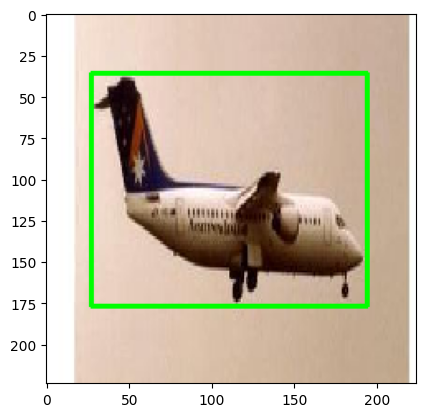

In [14]:
id = 10
image = list_images[id]
annot = list_annots[id]
class_name = list_classes[id]

x1, y1, x2, y2 = annot
cv2.rectangle(image, (int(x1*224), int(y1*224)), (int(x2*224), int(y2*224)), (0, 255, 0), 2)
plt.imshow(image)

In [22]:
lb = LabelBinarizer()

lb.fit(class_names)
list_classes_onehot = lb.transform(list_classes)
list_classes_onehot[:5]

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0]])

In [25]:
train_images, val_images, train_annots, val_annots, train_labels, val_labels = train_test_split(list_images, list_annots, list_classes_onehot, test_size=0.2, random_state=42)

print(f"Train images length: {len(train_images)}")
print(f"Validation images length: {len(val_images)}")
print(f"Train annotations length: {len(train_annots)}")
print(f"Validation annotations length: {len(val_annots)}")
print(f"Train labels length: {len(train_labels)}")
print(f"Validation labels length: {len(val_labels)}")

Train images length: 1624
Validation images length: 406
Train annotations length: 1624
Validation annotations length: 406
Train labels length: 1624
Validation labels length: 406


Text(0.5, 1.0, 'face')

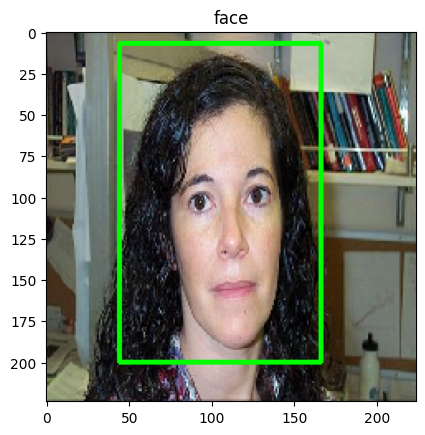

In [34]:
id = 1623
image = train_images[id]
annot = train_annots[id]
class_name = train_labels[id]

x1, y1, x2, y2 = annot
cv2.rectangle(image, (int(x1*224), int(y1*224)), (int(x2*224), int(y2*224)), (0, 255, 0), 2)
plt.imshow(image); plt.title(lb.classes_[class_name.argmax()])

In [ ]:
cnn_model = VGG16(include_top=False, weights="imagenet", input_tensor=tf.keras.layers.Input((224, 224, 3)))
cnn_model.trainable = False

In [ ]:
cnn_model.summary()

In [ ]:
input = keras.layers.Input(shape=(224, 224, 3))
x = cnn_model(input)
flatten = keras.layers.Flatten()(x)

bboxhead = keras.layers.Dense(128, activation='relu')(flatten)
bboxhead = keras.layers.Dense(64, activation='relu')(bboxhead)
bboxhead = keras.layers.Dense(32, activation='relu')(bboxhead)
bboxhead = keras.layers.Dense(4, activation='sigmoid', name='BBOX')(bboxhead)

softmaxhead = keras.layers.Dense(512, activation='relu')(flatten)
softmaxhead = keras.layers.Dropout(0.5)(softmaxhead)
softmaxhead = keras.layers.Dense(512, activation='relu')(softmaxhead)
softmaxhead = keras.layers.Dropout(0.5)(softmaxhead)
softmaxhead = keras.layers.Dense(len(lb.classes_), activation='softmax', name='CLASSNAME')(softmaxhead)

In [ ]:
model = Model(input, [bboxhead, softmaxhead])

3

In [ ]:
losses = {
    'BBOX': Huber,
    'CLASSNAME': CategoricalCrossentropy
}

lossWeights = {
    'BBOX': 1.0,
    'CLASSNAME': 1.0
}

In [ ]:
model.compile(optimizer=AdamW(learning_rate=0.0001), 
              loss=losses, 
              metrics=["accuracy"], 
              loss_weights=lossWeights)

In [ ]:
train_outputs = {
    'BBOX': train_annots,
    'CLASSNAME': train_labels
}

val_outputs = {
    'BBOX': val_annots,
    'CLASSNAME': val_labels
}

In [ ]:
history = model.fit(train_images, train_outputs, validation_data=(val_images, val_outputs), epochs=50, batch_size=32)